# Unsupervised Learning Algorithms: A Hands-On Walkthrough

Welcome to our hands-on walkthrough of unsupervised learning algorithms! In this notebook, we'll explore how to discover hidden patterns in data when we don't have labels to guide us.

**What we'll cover:**
1. Understanding unlabeled data
2. K-Means Clustering
3. PCA (Principal Component Analysis)
4. t-SNE (Visualizing Clusters)

**Our Scenario:** You're a data scientist at an e-commerce company. Marketing wants to understand your customer base better so they can create targeted campaigns. You have customer data, but no predefined categories - that's where unsupervised learning comes in!

---

## Setup: Import Libraries

Let's start by importing everything we'll need.

In [6]:
import numpy as np                              # Core libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans              # Clustering
from sklearn.decomposition import PCA           # Dimensionality reduction
from sklearn.manifold import TSNE               # t-SNE for visualization
from sklearn.metrics import silhouette_score    # Evaluation metrics
from sklearn.preprocessing import StandardScaler # Scaling data

np.random.seed(42)                              # Set random seed for reproducibility

print("All libraries imported successfully!")

All libraries imported successfully!


---

## Section 1: Understanding Our Customer Data

Let's create a simple customer dataset. In the real world, you'd load this from a database or CSV file.

**Our features:**
- `annual_spending`: How much the customer spends per year ($)
- `visit_frequency`: How often they visit per month

In [7]:
group1 = np.random.randn(8, 2) * 0.5 + [2, 2]   # Group 1: Low spenders, infrequent visitors
group2 = np.random.randn(8, 2) * 0.5 + [5, 7]   # Group 2: Medium spenders, frequent visitors  
group3 = np.random.randn(8, 2) * 0.5 + [8, 4]   # Group 3: High spenders, medium visitors

customers = np.vstack([group1, group2, group3]) # Combine all customers

shuffle_idx = np.random.permutation(len(customers))  # Shuffle the data so clusters aren't in order
customers = customers[shuffle_idx]

df = pd.DataFrame(customers, columns=['annual_spending', 'visit_frequency'])
df.index.name = 'customer_id'

print(f"Total customers: {len(df)}")
print("(Data has been shuffled - clusters are mixed throughout!)")
df.head(10)

Total customers: 24
(Data has been shuffled - clusters are mixed throughout!)


,annual_spending,visit_frequency
customer_id,,
0,8.104432,3.020165
1,2.789606,2.383717
2,1.768291,1.767135
3,2.323844,2.761515
4,1.765263,2.271280
5,4.545988,6.293848
6,8.369233,4.085684
7,8.411272,3.389578
8,4.699147,7.926139


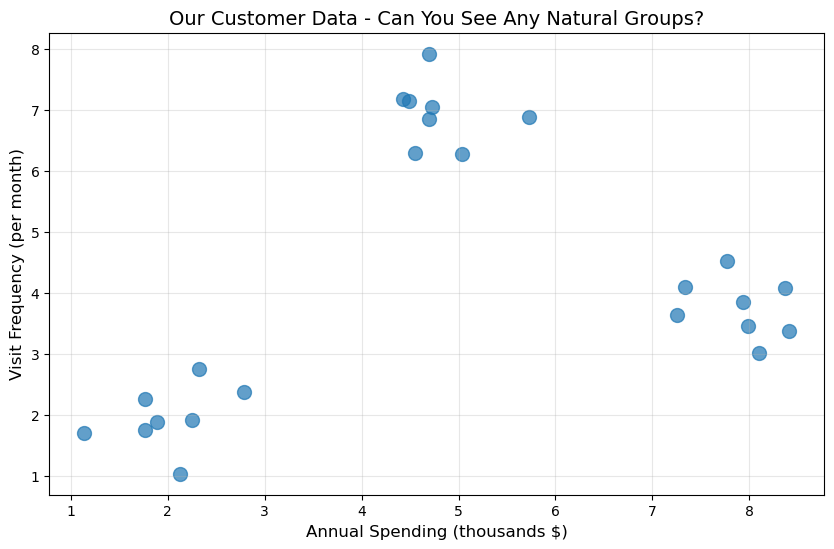

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['annual_spending'], df['visit_frequency'], s=100, alpha=0.7)
plt.xlabel('Annual Spending (thousands $)', fontsize=12)
plt.ylabel('Visit Frequency (per month)', fontsize=12)
plt.title('Our Customer Data - Can You See Any Natural Groups?', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

---

## Section 2: K-Means Clustering

K-Means is the most popular clustering algorithm. It works by:
1. Placing K random centroids (cluster centers)
2. Assigning each point to its nearest centroid
3. Moving centroids to the mean of their assigned points
4. Repeating until centroids stop moving

**Key requirement:** You must specify K (number of clusters) upfront!

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)  # Create K-Means with 3 clusters
kmeans.fit(customers)

cluster_labels = kmeans.labels_                  # Get cluster assignments for each customer
centroids = kmeans.cluster_centers_              # Get the centroid locations

print("Cluster assignments for each customer:")
print(cluster_labels)
print(f"\nCentroid locations:\n{centroids}")

Cluster assignments for each customer:
[2 1 1 1 1 0 2 2 0 0 2 1 0 2 1 0 2 2 1 1 2 0 0 0]

Centroid locations:
[[4.79466251 6.95616401]
 [2.00460091 1.96995787]
 [7.89833642 3.7603862 ]]


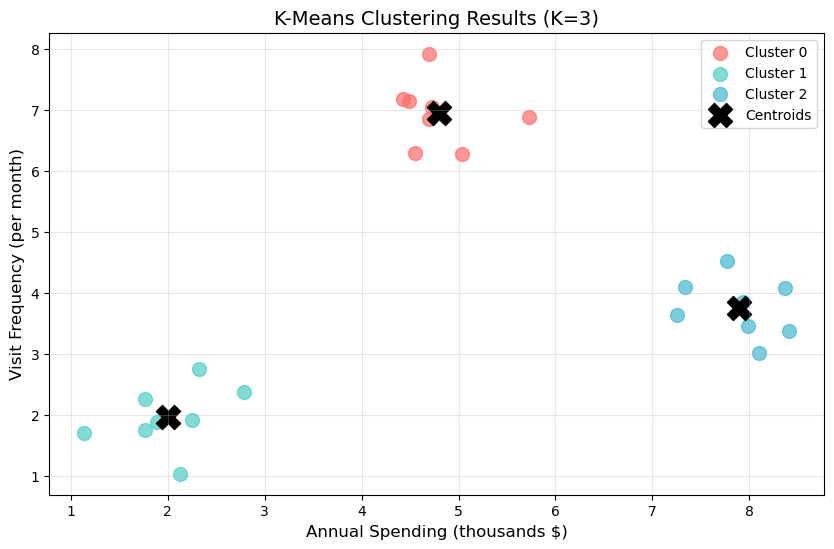


The X marks show the center of each cluster (centroid).
Each customer is assigned to the nearest centroid.


In [17]:
plt.figure(figsize=(10, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']       # Plot each cluster with a different color
for i in range(3):
    cluster_points = customers[cluster_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], s=100, alpha=0.7, label=f'Cluster {i}')

plt.scatter(centroids[:, 0], centroids[:, 1],    # Plot centroids
            c='black', marker='X', s=300, label='Centroids')

plt.xlabel('Annual Spending (thousands $)', fontsize=12)
plt.ylabel('Visit Frequency (per month)', fontsize=12)
plt.title('K-Means Clustering Results (K=3)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nThe X marks show the center of each cluster (centroid).")
print("Each customer is assigned to the nearest centroid.")

### How Do We Choose K? The Elbow Method

We don't always know how many clusters exist in our data. The **Elbow Method** helps us decide:
- Run K-Means for different values of K
- Plot the "inertia" (within-cluster sum of squares)
- Look for the "elbow" where the curve bends

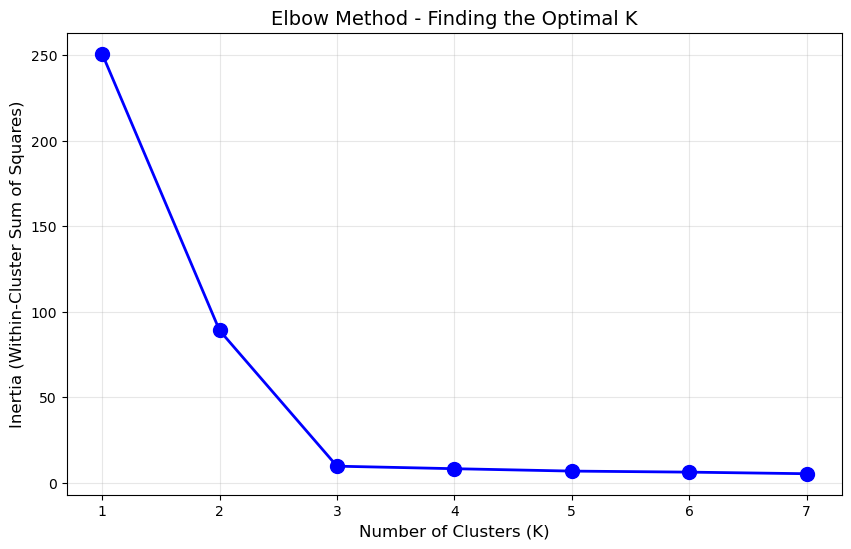

Look for the 'elbow' - where the curve bends sharply.
In this case, K=3 appears to be a good choice!


In [11]:
inertias = []
K_range = range(1, 8)

for k in K_range:                                # Run K-Means for different values of K
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(customers)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))                      # Plot the elbow curve
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method - Finding the Optimal K', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

print("Look for the 'elbow' - where the curve bends sharply.")
print("In this case, K=3 appears to be a good choice!")

### Evaluating Clusters: Silhouette Score

The **Silhouette Score** measures how well each point fits its cluster:
- Range: -1 to +1
- Higher is better
- Close to 1 = well-clustered

In [18]:
print("Silhouette Scores for Different K Values:")
print("-" * 40)

for k in range(2, 7):                            # Calculate silhouette scores for different K values
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(customers)
    score = silhouette_score(customers, labels)
    print(f"K={k}: Silhouette Score = {score:.3f}")

print("\nHigher scores indicate better-defined clusters.")

Silhouette Scores for Different K Values:
----------------------------------------
K=2: Silhouette Score = 0.635
K=3: Silhouette Score = 0.816
K=4: Silhouette Score = 0.638
K=5: Silhouette Score = 0.480
K=6: Silhouette Score = 0.465

Higher scores indicate better-defined clusters.


### Interpreting Our Customer Segments

Now let's understand what each cluster represents!

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(customers)    # Add cluster labels to our dataframe

cluster_stats = df.groupby('cluster').agg({      # Calculate cluster statistics
    'annual_spending': ['mean', 'count'],
    'visit_frequency': 'mean'
}).round(2)

print("Customer Segment Analysis:")
print("=" * 50)
print(cluster_stats)

print("\n\nSegment Interpretations:")
print("-" * 50)
for cluster in sorted(df['cluster'].unique()):
    avg_spending = df[df['cluster'] == cluster]['annual_spending'].mean()
    avg_visits = df[df['cluster'] == cluster]['visit_frequency'].mean()
    
    if avg_spending < 4 and avg_visits < 4:
        segment = "Budget Browsers - Low spending, infrequent visits"
    elif avg_visits > 5:
        segment = "Loyal Regulars - Frequent visitors, moderate spending"
    else:
        segment = "Premium Shoppers - High spending, occasional visits"
    
    print(f"Cluster {cluster}: {segment}")

Customer Segment Analysis:
        annual_spending       visit_frequency
                   mean count            mean
cluster                                      
0                  4.79     8            6.96
1                  2.00     8            1.97
2                  7.90     8            3.76


Segment Interpretations:
--------------------------------------------------
Cluster 0: Loyal Regulars - Frequent visitors, moderate spending
Cluster 1: Budget Browsers - Low spending, infrequent visits
Cluster 2: Premium Shoppers - High spending, occasional visits


---

## Section 3: PCA (Principal Component Analysis)

PCA is a **dimensionality reduction** technique. It helps when you have:
- Too many features to visualize
- Redundant/correlated features
- Need to speed up machine learning

**How it works:** Find new axes (principal components) that capture the most variance in your data.

In [20]:
np.random.seed(42)
n_customers = 50

customer_data = pd.DataFrame({                   # Create a higher-dimensional customer dataset (6 features)
    'annual_spending': np.random.normal(50, 20, n_customers),
    'visit_frequency': np.random.normal(10, 4, n_customers),
    'avg_order_value': np.random.normal(75, 25, n_customers),
    'items_per_order': np.random.normal(5, 2, n_customers),
    'returns_rate': np.random.normal(0.1, 0.05, n_customers),
    'account_age_months': np.random.normal(24, 12, n_customers)
})

print("Customer data with 6 features:")
print(f"Shape: {customer_data.shape}")
customer_data.head()

Customer data with 6 features:
Shape: (50, 6)


,annual_spending,visit_frequency,avg_order_value,items_per_order,returns_rate,account_age_months
0,59.934283,11.296336,39.615731,5.500986,0.117889,8.869393
1,47.234714,8.459671,64.483867,5.692896,0.128039,35.014343
2,62.953771,7.292312,66.432137,3.639951,0.154153,49.465874
3,80.460597,12.446705,54.943068,5.464507,0.152690,36.389583
4,45.316933,14.123998,70.967857,5.586145,0.031117,5.767560


In [21]:
scaler = StandardScaler()                        # Always scale your data before PCA!
scaled_data = scaler.fit_transform(customer_data)

print("Data has been standardized (mean=0, std=1 for each feature)")
print(f"Shape: {scaled_data.shape}")

Data has been standardized (mean=0, std=1 for each feature)
Shape: (50, 6)


In [22]:
pca = PCA(n_components=2)                        # Apply PCA to reduce to 2 components
pca_result = pca.fit_transform(scaled_data)

print(f"Original shape: {scaled_data.shape}")
print(f"After PCA: {pca_result.shape}")
print(f"\nWe reduced 6 dimensions to 2!")

Original shape: (50, 6)
After PCA: (50, 2)

We reduced 6 dimensions to 2!


In [23]:
print("Explained Variance Ratio:")                # How much information did we keep?
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"\nTotal: {sum(pca.explained_variance_ratio_):.2%} of variance explained!")

print("\nThis means our 2D representation captures about",
      f"{sum(pca.explained_variance_ratio_):.0%} of the original information.")

Explained Variance Ratio:
PC1: 26.63%
PC2: 23.56%

Total: 50.19% of variance explained!

This means our 2D representation captures about 50% of the original information.


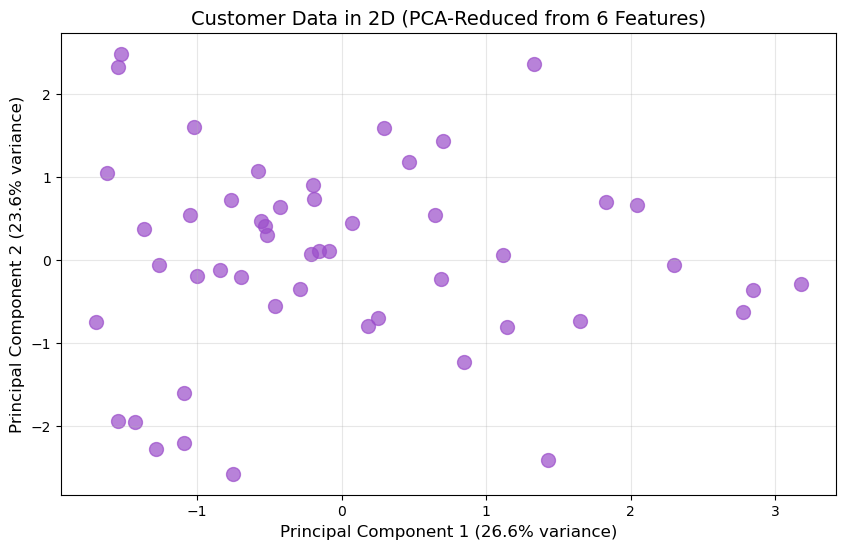


Now we can visualize 6-dimensional customer data in 2D!
We can also apply K-Means to this reduced data for faster clustering.


In [24]:
plt.figure(figsize=(10, 6))                      # Visualize the PCA-reduced data
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=100, alpha=0.7, c='#9B4DCA')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('Customer Data in 2D (PCA-Reduced from 6 Features)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("\nNow we can visualize 6-dimensional customer data in 2D!")
print("We can also apply K-Means to this reduced data for faster clustering.")

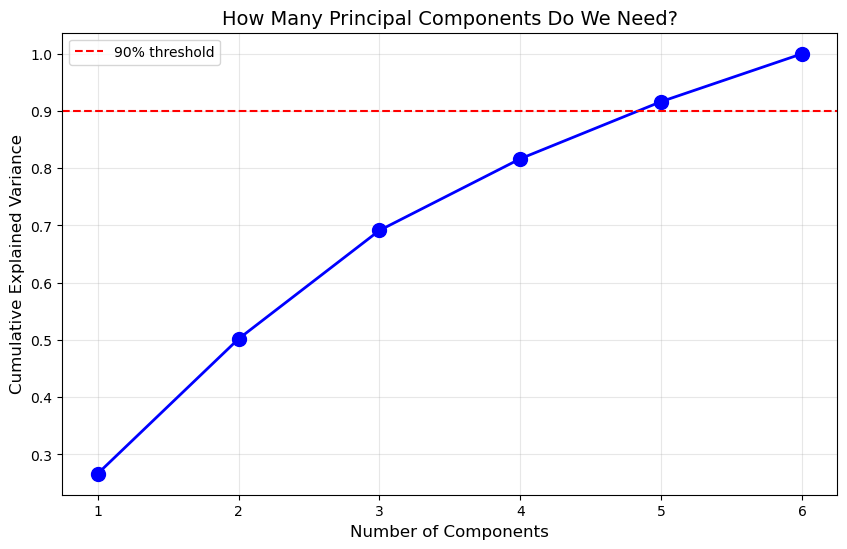


To keep 90% of the variance, we need 5 components.
That's a reduction from 6 to 5 features!


In [25]:
pca_full = PCA()                                 # Fit PCA with all components
pca_full.fit(scaled_data)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)  # Cumulative explained variance

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', linewidth=2, markersize=10)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('How Many Principal Components Do We Need?', fontsize=14)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1  # Find components for 90% variance
print(f"\nTo keep 90% of the variance, we need {n_components_90} components.")
print(f"That's a reduction from 6 to {n_components_90} features!")

---

## Section 4: t-SNE (Visualizing Clusters)

**t-SNE** (t-Distributed Stochastic Neighbor Embedding) is another dimensionality reduction technique, but with a different goal:

- **PCA:** Preserve global structure and variance
- **t-SNE:** Preserve local structure - keep similar points close together

**Key point:** t-SNE is for **visualization only** - don't use it for downstream ML models!

In [26]:
# Let's create data with clear clusters to see t-SNE in action
np.random.seed(42)

cluster1 = np.random.randn(30, 6) * 0.5 + [1, 1, 1, 1, 1, 1]   # 3 distinct clusters in 6D space
cluster2 = np.random.randn(30, 6) * 0.5 + [5, 5, 5, 5, 5, 5]
cluster3 = np.random.randn(30, 6) * 0.5 + [9, 2, 9, 2, 9, 2]

high_dim_clusters = np.vstack([cluster1, cluster2, cluster3])
true_labels = [0]*30 + [1]*30 + [2]*30           # We know the true clusters (for coloring)

print(f"Data shape: {high_dim_clusters.shape}")
print("We have 90 points in 6-dimensional space with 3 natural clusters.")

Data shape: (90, 6)
We have 90 points in 6-dimensional space with 3 natural clusters.


In [27]:
# Compare PCA vs t-SNE on the same data
scaler = StandardScaler()
scaled_clusters = scaler.fit_transform(high_dim_clusters)

pca = PCA(n_components=2)                        # PCA reduction
pca_result = pca.fit_transform(scaled_clusters)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)  # t-SNE reduction
tsne_result = tsne.fit_transform(scaled_clusters)

print("Both reductions complete!")
print(f"PCA result shape: {pca_result.shape}")
print(f"t-SNE result shape: {tsne_result.shape}")

Both reductions complete!
PCA result shape: (90, 2)
t-SNE result shape: (90, 2)


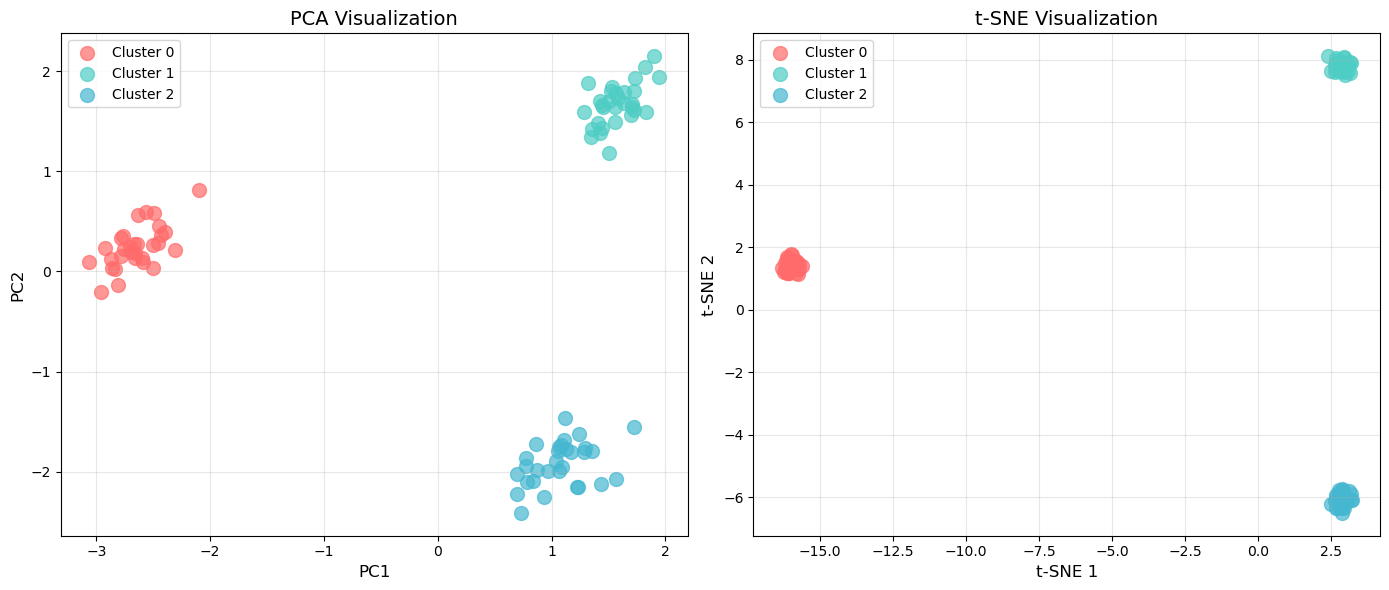


Notice how t-SNE creates tighter, more separated clusters!
This makes it easier to visually identify distinct groups in your data.


In [28]:
# Side-by-side comparison: PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# PCA plot
for i, color in enumerate(colors):
    mask = np.array(true_labels) == i
    axes[0].scatter(pca_result[mask, 0], pca_result[mask, 1], 
                    c=color, s=100, alpha=0.7, label=f'Cluster {i}')
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('PCA Visualization', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE plot
for i, color in enumerate(colors):
    mask = np.array(true_labels) == i
    axes[1].scatter(tsne_result[mask, 0], tsne_result[mask, 1], 
                    c=color, s=100, alpha=0.7, label=f'Cluster {i}')
axes[1].set_xlabel('t-SNE 1', fontsize=12)
axes[1].set_ylabel('t-SNE 2', fontsize=12)
axes[1].set_title('t-SNE Visualization', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNotice how t-SNE creates tighter, more separated clusters!")
print("This makes it easier to visually identify distinct groups in your data.")

---

## Key Takeaways

1. **Unsupervised learning** finds patterns without labeled data
2. **K-Means** is fast and simple - great for customer segmentation
3. **Elbow Method** helps you choose the optimal number of clusters
4. **Silhouette Score** measures how well-defined your clusters are
5. **PCA** reduces dimensions while preserving variance
6. **t-SNE** is powerful for visualizing clusters in high-dimensional data

---

# Optional Challenges

Ready to practice on your own? Try these challenges!

---

## Challenge 1: K-Means - Product Segmentation

You have data about products in an online store. Use K-Means to segment them into groups.

**Tasks:**
1. Use the elbow method to find the optimal K
2. Apply K-Means with that K
3. Interpret what each product segment might represent

In [29]:
np.random.seed(123)

products = pd.DataFrame({                        # Product features
    'price': [15, 18, 22, 45, 52, 48, 120, 135, 142, 89, 95, 88],
    'units_sold': [500, 480, 520, 200, 180, 210, 50, 45, 55, 150, 160, 145]
})

print("Product data:")
print(products)

# YOUR CODE HERE:
# 1. Use elbow method to find optimal K
# 2. Apply K-Means
# 3. Visualize and interpret the clusters

Product data:
    price  units_sold
0      15         500
1      18         480
2      22         520
3      45         200
4      52         180
5      48         210
6     120          50
7     135          45
8     142          55
9      89         150
10     95         160
11     88         145


## Challenge 2: PCA - Feature Reduction

You have a dataset with 8 features. Reduce it to capture at least 85% of the variance.

**Tasks:**
1. Scale the data
2. Apply PCA and find how many components capture 85% variance
3. Visualize the cumulative explained variance

In [30]:
np.random.seed(789)

high_dim_data = pd.DataFrame({                   # 8-dimensional dataset
    'feature_1': np.random.normal(10, 3, 40),
    'feature_2': np.random.normal(20, 5, 40),
    'feature_3': np.random.normal(15, 4, 40),
    'feature_4': np.random.normal(8, 2, 40),
    'feature_5': np.random.normal(25, 6, 40),
    'feature_6': np.random.normal(12, 3, 40),
    'feature_7': np.random.normal(18, 4, 40),
    'feature_8': np.random.normal(22, 5, 40)
})

print(f"Original shape: {high_dim_data.shape}")
print("\nFirst 5 rows:")
print(high_dim_data.head())

# YOUR CODE HERE:
# 1. Scale the data
# 2. Apply PCA
# 3. Find components needed for 85% variance
# 4. Visualize cumulative explained variance

Original shape: (40, 8)

First 5 rows:
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   6.675666  23.120514  15.029478   5.168160  26.087740  10.342524   
1   7.822844  11.283405  21.252662   3.371685  15.580222  17.194657   
2  11.568413  23.565350   9.348802   8.011622  26.193598  12.027206   
3  13.703326  16.703697  19.202809   6.784198  28.097023  12.109562   
4  10.290688   9.401984  10.372062   4.258824  24.328605  11.164771   

   feature_7  feature_8  
0  18.856774  15.579545  
1   7.246501  24.359232  
2  16.644763  19.465086  
3  20.321301  24.769601  
4  14.400026  23.972692  


---

## Congratulations!

You've completed the Unsupervised Learning walkthrough!

**What you've learned:**
- How to use K-Means clustering for customer segmentation
- How to choose the right number of clusters (Elbow Method)
- How to evaluate clusters with Silhouette Score
- How to reduce dimensions with PCA
- How to visualize high-dimensional clusters with t-SNE

**What's next:** Unit 4 - Deep Learning & Neural Networks!

---